# Анализ доходности и оценок — Мария

## Бюджет и кассовые сборы

Данные о бюджете и мировых сборах получены в большой степени с сайта https://www.the-numbers.com. Данные в таблице содержатся по 90 строкам, однако если учитывать год выпуска, то 68. Некторые данные не удалось извлечь, так как не у всех фильмов есть "Worldwide Box Office" и/или данных о бюджете (пример: Wiener Dog Internationals). Также был изучен сайт https://www.boxofficemojo.com/title/tt4144190/?ref_=bo_se_r_1$0, на которох также не было данных (пример: фильма с названием "Wiener Dog Internationals" нет, есть только "Wiener Dog").

Дополнительно были изучены датасеты с сайта Kaggle, но данных о бюджете и доходах для слияния было недостаточно (около 50 соединений, последующее слияние датасетов к значительному увелечению данных не приводило). Изучены доступные датасеты от IMDb (IMDb Non-Commercial Datasets https://developer.imdb.com/non-commercial-datasets/$0), в которых также нет данных о финансах.

На форуме Reddit (https://www.reddit.com/r/datasets/comments/gn5hp7/dataset_for_box_office_releases_19702020/$0) удалось найти большой датасет. При его обработке был учен комментарий, что много 0 в колонке бюджет (This isn't accurate. Whole swathes of movies are listed to have budgets of zero and revenue in the ones-place). К итоговому датасету добавилось 19 строк по бюджету.

Скорее всего данные не доступны в связи с коммерческой тайной (оценка гонорара актеров, финансовые возможности компании и т.д.), а имеющиеся информационные источники берут информацию друг у друга.

## подготовка датасета для анализа успешности по финансовым показателям

In [297]:
import pandas as pd
data = pd.read_csv("NetflixShows_clear.csv")
data.head(1)

,Unnamed: 0,index,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,type,audience_segment,genre,country,imdbRating,imdbVotes,rated
0,0,0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.000,80,"crude and sexual humor, language and some drug...",movie,Teens,"Comedy, Crime",United States,5.900,"190,250",PG-13


In [298]:
#датасет, полученный с сайта  https://www.the-numbers.com и https://www.boxofficemojo.com/
df_budget = pd.read_excel("movie_financials_the_numbers_boxofficemojo.xlsx")
df_budget["release year"] = pd.to_datetime(df_budget["Release Date / Year"],errors="coerce").dt.year.astype("Int64")
df_budget = df_budget.drop(columns=["Matched Title", "Release Date / Year", 'Match Status', 'Source'])
df_budget = df_budget.dropna(subset=["release year", 'Worldwide Box Office', 'Production Budget'])
df_budget

,Title,Worldwide Box Office,Production Budget,release year
0,White Chicks,111448997.000,20000000.000,2004
1,Lucky Number Slevin,55495466.000,27000000.000,2006
29,Scream,173046663.000,15000000.000,1996
73,Zootopia,1019429616.000,150000000.000,2016
74,Meet the Blacks,9097072.000,900000.000,2016
...,...,...,...,...
469,Pooh's Heffalump Movie,55686944.000,20000000.000,2005
471,Corpse Bride,114770654.000,30000000.000,2005
473,Underdogs,1392649.000,2500000.000,2013
477,Baby's Day Out,16581575.000,50000000.000,1994


In [299]:
pd.set_option("display.float_format", "{:.0f}".format)
#глобальная найстрока для отображения float
#https://sky.pro/wiki/python/formatirovanie-chisel-bez-nauchnoy-notatsii-v-pandas/

In [300]:
#объединение основного датасета и данные по бюджету
df_new = pd.merge(data, df_budget, left_on=['title', 'release year'], right_on=['Title','release year'], how='left')
df_new = df_new.drop(columns='Title')
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            500 non-null    int64  
 1   index                 500 non-null    int64  
 2   title                 500 non-null    object 
 3   rating                500 non-null    str    
 4   ratingLevel           500 non-null    str    
 5   release year          500 non-null    int64  
 6   user rating score     256 non-null    float64
 7   user rating size      500 non-null    int64  
 8   sceneDesc             89 non-null     str    
 9   type                  489 non-null    str    
 10  audience_segment      500 non-null    str    
 11  genre                 134 non-null    str    
 12  country               133 non-null    str    
 13  imdbRating            134 non-null    float64
 14  imdbVotes             134 non-null    str    
 15  rated                 134 non-null

In [301]:
#добавление второго датасета с сайта Kaggle
df_budget2 = pd.read_csv('movies_metadata.csv')
#df_budget2.columns.tolist()
df_budget2['budget'] = pd.to_numeric(df_budget2['budget'], errors='coerce').astype('float64')
#df_budget2.info()
df_budget2_clean = df_budget2[df_budget2['budget'] != 0] #на редите было сказано, что много 0, поэтому можно сразу отсеять
df_budget2_clean = df_budget2_clean.drop_duplicates(subset=['title', 'release_date'], keep='first')
df_budget2_clean['release year'] = pd.to_datetime(df_budget2_clean['release_date'], errors='coerce').dt.year.astype('Int64')

df_budget2_clean.info()


<class 'pandas.DataFrame'>
Index: 8883 entries, 0 to 45422
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  8883 non-null   str    
 1   belongs_to_collection  1587 non-null   str    
 2   budget                 8880 non-null   float64
 3   genres                 8883 non-null   str    
 4   homepage               2756 non-null   str    
 5   id                     8883 non-null   str    
 6   imdb_id                8881 non-null   str    
 7   original_language      8883 non-null   str    
 8   original_title         8883 non-null   str    
 9   overview               8836 non-null   str    
 10  popularity             8881 non-null   object 
 11  poster_path            8876 non-null   str    
 12  production_companies   8883 non-null   str    
 13  production_countries   8883 non-null   str    
 14  release_date           8879 non-null   str    
 15  revenue            

/var/folders/_w/1360zfs92kv0_ffpdtv1d0_m0000gn/T/ipykernel_74431/1729141967.py:2: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_budget2 = pd.read_csv('movies_metadata.csv')


In [302]:
#объединение основного датасета (df + df_budget) со второмым c Reddit/Kaggle
df_full = pd.merge(df_new, df_budget2_clean[['original_title', 'budget', 'production_companies', 'production_countries', 'release year', 'runtime', 'revenue']], left_on=['title', 'release year'], right_on=['original_title', 'release year'], how='left')
df_full['Production Budget'] = df_full['Production Budget'].fillna(df_full['budget'])
df_full['Worldwide Box Office'] = df_full['Worldwide Box Office'].fillna(df_full['revenue'])
df_full = df_full.drop(columns=['original_title', 'budget'])
df_full.shape

(500, 22)

In [303]:
df_full = df_full.dropna(subset=['Worldwide Box Office', 'Production Budget'])
df_full.info()

<class 'pandas.DataFrame'>
Index: 87 entries, 0 to 492
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            87 non-null     int64  
 1   index                 87 non-null     int64  
 2   title                 87 non-null     object 
 3   rating                87 non-null     str    
 4   ratingLevel           87 non-null     str    
 5   release year          87 non-null     int64  
 6   user rating score     65 non-null     float64
 7   user rating size      87 non-null     int64  
 8   sceneDesc             61 non-null     str    
 9   type                  86 non-null     str    
 10  audience_segment      87 non-null     str    
 11  genre                 81 non-null     str    
 12  country               81 non-null     str    
 13  imdbRating            81 non-null     float64
 14  imdbVotes             81 non-null     str    
 15  rated                 81 non-null     st

In [304]:
df_full = df_full.drop(columns=['index','Unnamed: 0', 'rated', 'country', 'imdbRating', 'imdbVotes', 'sceneDesc', 'revenue'])

In [305]:
df_full.head(2)

,title,rating,ratingLevel,release year,user rating score,user rating size,type,audience_segment,genre,Worldwide Box Office,Production Budget,production_companies,production_countries,runtime
0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82,80,movie,Teens,"Comedy, Crime",111448997,20000000,"[{'name': 'Columbia Pictures', 'id': 5}, {'nam...","[{'iso_3166_1': 'US', 'name': 'United States o...",109
1,Lucky Number Slevin,R,Restricted. May be inappropriate for children ...,2006,NaN,82,movie,Adults,"Crime, Drama, Thriller",55495466,27000000,"[{'name': 'The Weinstein Company', 'id': 308},...","[{'iso_3166_1': 'DE', 'name': 'Germany'}, {'is...",110


In [306]:
df_full["Production Budget"].min()
#значение неадекватное для бюджета фильма, поэтому лучше удалить строки меньше 100к долларов

np.float64(5.0)

In [307]:
df_full = df_full[df_full["Production Budget"] >=100000]
df_full.shape

(86, 14)

In [308]:
df_full["Worldwide Box Office"].min()

np.float64(0.0)

In [309]:
df_full = df_full[df_full["Worldwide Box Office"] != 0]

In [310]:
df_full["Worldwide Box Office"].min()

np.float64(5940.0)

### создание новых признаков:
- прибыль фильма (Мировой кассовый сбор - бюджет)
- процент прибыль (Мировой кассовый сбор/ бюджет*100)


In [311]:
df_full['profit'] = df_full['Worldwide Box Office'] - df_full['Production Budget']

In [312]:
df_full['profit perc'] = round((df_full['profit'] / df_full['Production Budget']) *100, 2)

In [313]:
df_full["success"] = df_full['profit']> 0

In [314]:
df_full.head(1)

,title,rating,ratingLevel,release year,user rating score,user rating size,type,audience_segment,genre,Worldwide Box Office,Production Budget,production_companies,production_countries,runtime,profit,profit perc,success
0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82,80,movie,Teens,"Comedy, Crime",111448997,20000000,"[{'name': 'Columbia Pictures', 'id': 5}, {'nam...","[{'iso_3166_1': 'US', 'name': 'United States o...",109,91448997,457,True


In [315]:
df_full.groupby(['type']).size()

type
movie    75
tv        3
dtype: int64

In [316]:
df_full  = df_full[df_full['type']== 'movie']

In [317]:
df_full.groupby(['type']).size()

type
movie    75
dtype: int64

## анализ успешности фильмов по финансовым показателям (бюджет и сборы)

In [318]:
df_full["Production Budget"].describe()

count          75
mean     57482400
std      47594931
min        900000
25%      20000000
50%      50000000
75%      77500000
max     200000000
Name: Production Budget, dtype: float64

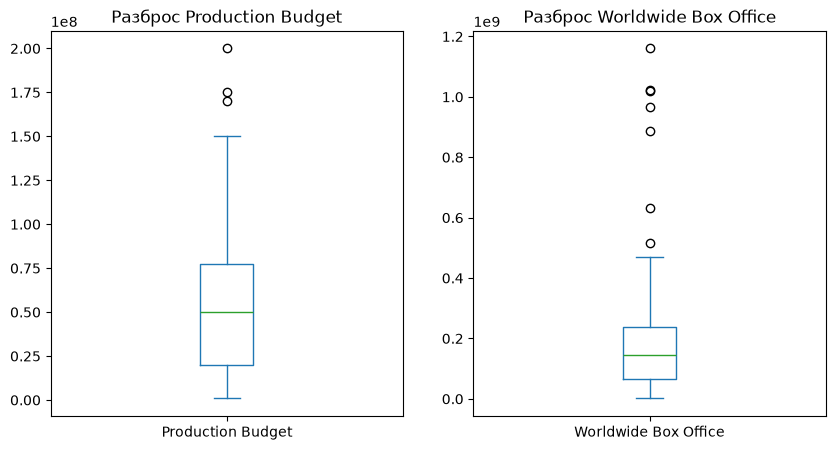

In [319]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
df_full['Production Budget'].plot(kind="box", ax=axes[0])
axes[0].set_title('Разброс Production Budget')
df_full['Worldwide Box Office'].plot(kind="box", ax=axes[1])
axes[1].set_title("Разброс Worldwide Box Office")

plt.show()

In [320]:
#удаляем только 1 строку в Production budget и 1 в сборах 
df_full = df_full.drop(index=df_full["Production Budget"].idxmax())
df_full = df_full.drop(index=df_full["Worldwide Box Office"].idxmax())
#https://sky.pro/wiki/python/poisk-strok-s-maksimalnym-znacheniem-v-pandas-data-frame/?ysclid=mqo76pqrpf97126523 

In [321]:
import seaborn as sns

(73, 5)

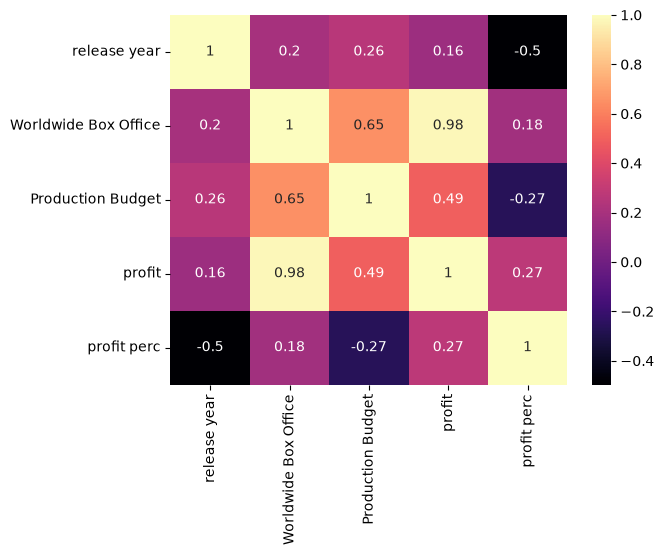

In [322]:
pd.set_option('display.float_format', '{:.3f}'.format)
corr_data = df_full[['release year', 'Worldwide Box Office', 'Production Budget', 'profit', 'profit perc']].dropna()
sns.heatmap(corr_data.corr(), cmap = 'magma', annot=True)
corr_data.shape

#### вывод 1: 
есть очень cильная корреляция между прибылью и кассовыми сборами, что может говорить, что рассматриваемые фильмы имеют хорошую окупаемость (0,98), однако в процентном соотношении корреляция слабая (0,18)
#### вывод 2: 
заметная корреляция между бюджетом фильма и сборами, что может означать, что у более дорогих картин - больше сборы (0,66), так же заметная корреляция между бюджетом и суммой дохода (0.56)
#### вывод 3:
год релиза отрицательно коррелирует с процентом прибыли, из чего можно предполагать, что более новые фильмы - менее окупаемы. Можно предположить, что доходность падает, так как растет переход аудитории в онлайн формат в плане потребления контента. Здесь могут также выступать причинами пиратское потребление контента или формат подписки (покупка пакета услуг, а не каждой отдельной единицы контента) 


In [323]:
#для дальнейшего анализа удаляем выбросы, чтобы посмотреть корректно среднее
Q1 = df_full["Production Budget"].quantile(0.25)
Q3 = df_full["Production Budget"].quantile(0.75)
IQR = Q3 - Q1
lw = Q1 - 1.5 * IQR
up = Q3 + 1.5 * IQR
df_full_clean = df_full[(df_full["Production Budget"] >= lw)&(df_full['Production Budget']<=up)]

In [324]:
df_full_clean.groupby("success")[['Production Budget', 'Worldwide Box Office', 'user rating score', 'runtime', 'profit perc']].median()

,Production Budget,Worldwide Box Office,user rating score,runtime,profit perc
success,,,,,
False,50000000.000,31333917.000,74.000,95.500,-30.840
True,46000000.000,156980793.500,84.000,95.000,245.950


#### вывод 4:
- средняя оценка значительно (на 10 из 100 баллов) ниже у "провальных" картин, чем у успешных, однако затрат в среднем больше, а сборов меньше 
- успешный контент может иметь меньший бюджет, но в разы больше сборов

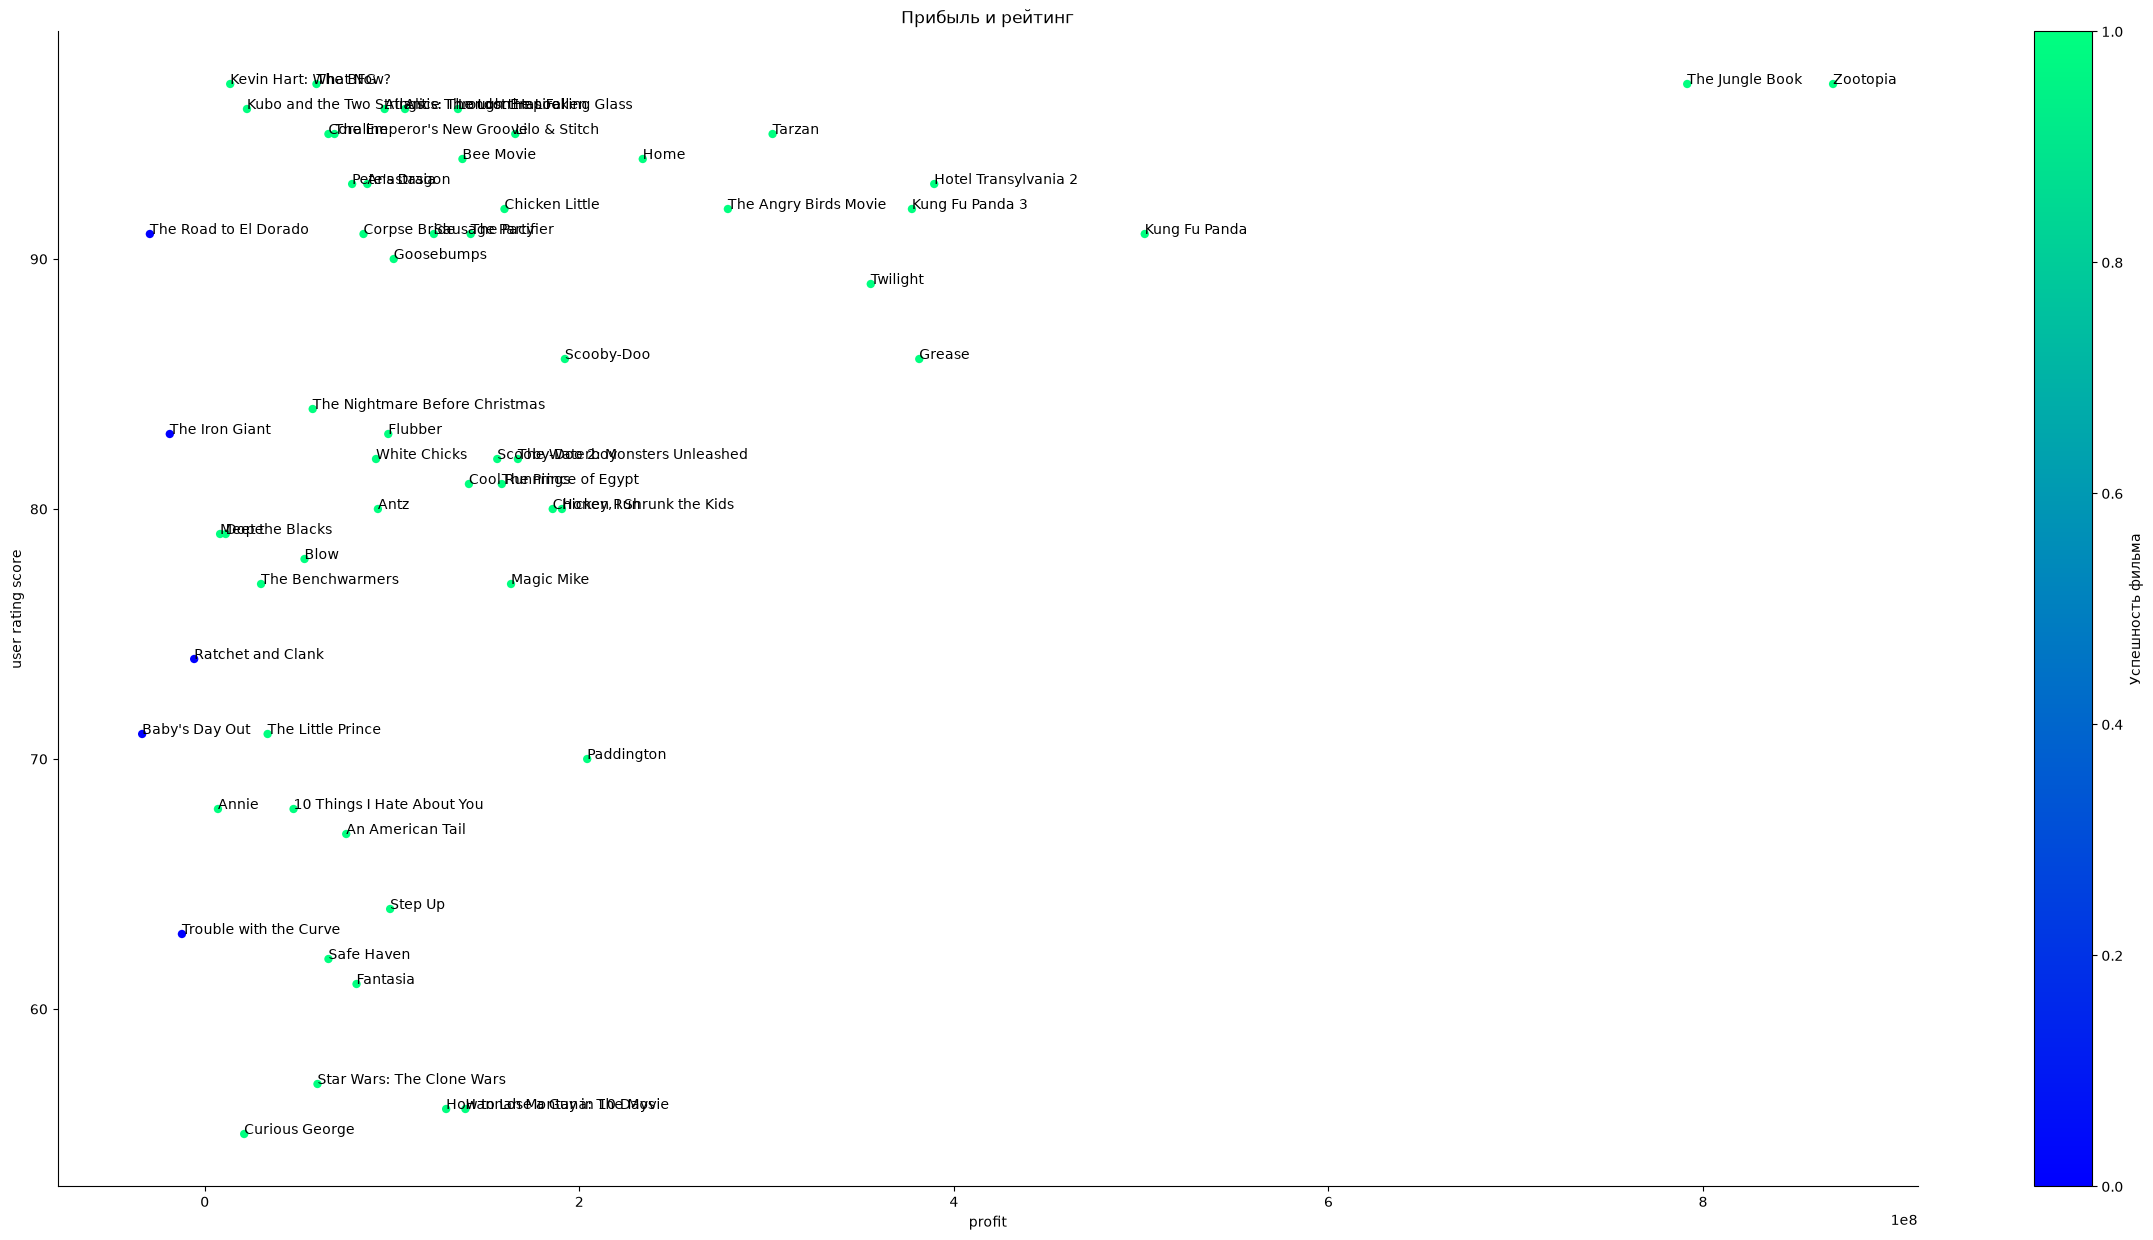

In [368]:
#из материалов по визуализации :B (Additional 2 - Advanced visualizations)
fig, ax = plt.subplots(figsize=(30, 15))

color_graph = ax.scatter(
    df_full['profit'],
    df_full['user rating score'],
    c=df_full['profit'] > 0,
    cmap='winter',
    alpha=1,
    linewidth=0
)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

for i in df_full.index:
    ax.text(
        df_full.loc[i, 'profit'],
        df_full.loc[i, 'user rating score'],
        df_full.loc[i, 'title'],
        fontsize=10
    )

ax.set_xlabel('profit')
ax.set_ylabel('user rating score')
ax.set_title("Прибыль и рейтинг")

plt.colorbar(color_graph, label='Успешность фильма')

plt.show()

#### вывод 5: 
- наличие прибыли фильма не отражает успешность фильма по рейтингу среди зрителей

#### ОДНАКО: оценивать фильм по сборам в данном формате считаем некорректным,, так как информации о методе подсчета данных нет. Каждый фильм использует свою методику и сценарий (только кассовый сбор в кинотеатрах, проект окупился - прекращение отслеживания/обновления данных, учет доходности со стриминговых платформ и т.д.)

#### ПОЭТОМУ: успешность картины лучше рассчитать по оценкам пользователей, так как они имеют накопительный эффект и регулярно обновляются

# Анализ успешности фильма на основе user rating score
### подготовка датасета

In [326]:
df_rating = data.dropna(subset=["user rating score"])
#

In [327]:
df_rating["type"].value_counts(dropna=False)

type
tv       171
movie     83
NaN        2
Name: count, dtype: int64

- пропуски можно удалить, а тв/фильмы сделать бинарным признаком

In [328]:
df_rating = df_rating.dropna(subset=["type"])

In [329]:
df_rating["movie"] = df_rating["type"].map({"movie": 1, 'tv': 0})

In [330]:
df_rating["user rating size"].describe()

count   254.000
mean     80.000
std       0.000
min      80.000
25%      80.000
50%      80.000
75%      80.000
max      80.000
Name: user rating size, dtype: float64

- std=0, а значит везде одинаковый объем наблюдений, что делает сравнение по оценкам корректным 

In [331]:
df_rating['imdbVotes'].agg(['min', 'max'])

min    10,065
max    99,482
Name: imdbVotes, dtype: str

- в добавленных данных по imdbVotes объем наблюдений рознится, поэтому к добавленным данным будет обращаться справочно, отдавая приоритет данным из первичного датасета, также меньше строк содержит данные по этому признаку 

In [332]:
df_rating["user rating score"].describe()

count   254.000
mean     81.433
std      12.651
min      55.000
25%      71.000
50%      83.500
75%      92.750
max      99.000
Name: user rating score, dtype: float64

In [333]:
df_rating.head(2)

,Unnamed: 0,index,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,type,audience_segment,genre,country,imdbRating,imdbVotes,rated,movie
0,0,0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.000,80,"crude and sexual humor, language and some drug...",movie,Teens,"Comedy, Crime",United States,5.900,"190,250",PG-13,1
2,2,2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,2016,98.000,80,NaN,tv,Teens,NaN,NaN,NaN,NaN,NaN,0


### анализ

<Axes: title={'center': 'Количество фильмов и тв'}, ylabel='type'>

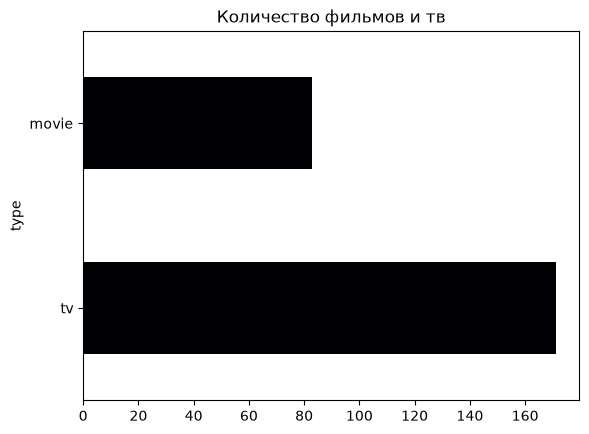

In [334]:
df_rating["type"].value_counts().plot(kind="barh", colormap="magma", title="Количество фильмов и тв")

/var/folders/_w/1360zfs92kv0_ffpdtv1d0_m0000gn/T/ipykernel_74431/1673530412.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rating, x="movie", y="user rating score",  palette="autumn")


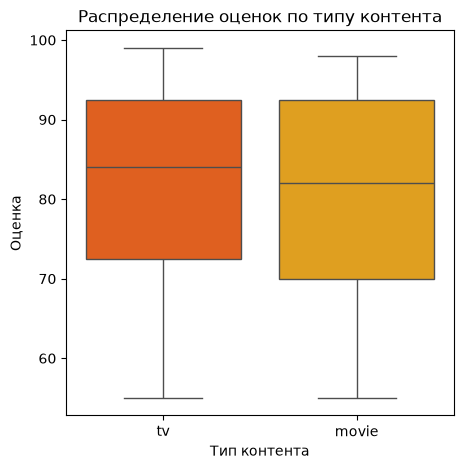

In [335]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df_rating, x="movie", y="user rating score",  palette="autumn")
plt.xticks([0, 1], ['tv', 'movie']) 
plt.title("Распределение оценок по типу контента")
plt.xlabel("Тип контента")
plt.ylabel("Оценка")
plt.show()

#### вывод 6:
разница в кол-ве тв-шоу и фильмов критично не влияет на распреедление оценок (оно примерно одинанковое)

In [336]:
df_rating['audience_segment'].value_counts()

audience_segment
Teens     86
Family    69
Kids      52
Adults    47
Name: count, dtype: int64

In [337]:
df_rating.groupby("audience_segment")['user rating score'].median().sort_values(ascending=False)

audience_segment
Adults   89.000
Family   86.000
Teens    84.000
Kids     73.500
Name: user rating score, dtype: float64

/var/folders/_w/1360zfs92kv0_ffpdtv1d0_m0000gn/T/ipykernel_74431/929936393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rating, x="audience_segment", y="user rating score", palette='Pastel2')


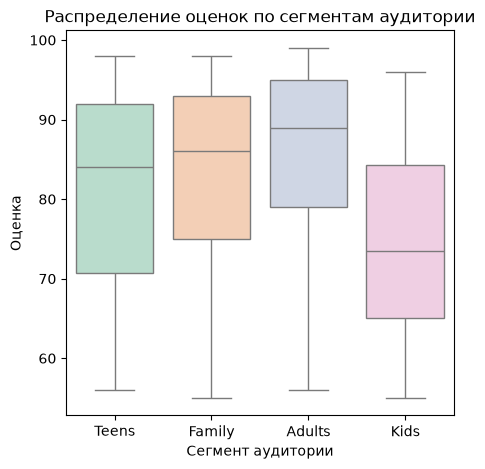

In [338]:
#выбросов нет
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df_rating, x="audience_segment", y="user rating score", palette='Pastel2')
plt.title("Распределение оценок по сегментам аудитории")
plt.xlabel("Сегмент аудитории")
plt.ylabel("Оценка")
plt.show()
#https://seaborn.pydata.org/generated/seaborn.boxplot.html

#### вывод 7: 
 Контент сегмента "взрослые" в среднем получает высокие оценки, чуть ниже семейный и подростковый контент. Детский контент менее удовлетворяет запросу зрителя (но, скорее всего родители/взрослые ставят оценки детским передачам, поэтому контент не соотствует запросам взрослых, что должен смотреть ребенок). (Также можно заметить, что выбросов нет)

In [339]:
df_rating.groupby(["audience_segment", 'type'])["user rating score"].agg(["median", "count"])

median  count
audience_segment type                
Adults           movie  79.000      7
                 tv     89.000     40
Family           movie  86.000     48
                 tv     88.000     21
Kids             movie  70.000     19
                 tv     74.000     33
Teens            movie  68.000      9
                 tv     86.000     77

 #### вывод 8: 
 рассматривать дополнительно группировку к сегменту по фильмам или шоу - некорректно, так как например у подростков  в фильмах 9 строк, а в тв-шоу 77 (дополнительный анализ по фильмам и ТВ-шоу представлен в блоках 4 и 5)

## анализ успешности фильмов на основе оценок

In [340]:
df_rating = df_rating[df_rating["movie"] == 1]

In [341]:
df_rating["sceneDesc"].unique()

<StringArray>
[                          'crude and sexual humor, language and some drug content',
                                    'some thematic elements, rude humor and action',
                  'pervasive language, some sexual material, violence and drug use',
                                                           'mild thematic elements',
                    'strong crude sexual content, pervasive language, and drug use',
                                             'for action, peril and brief language',
                                    'some sexual material, and language throughout',
  'language, drug content, sexuality/nudity, and some violence-all involving teens',
                                'thematic elements, scary images, action and peril',
                                               'for thematic material and language',
                                                                                nan,
                                             'langu

In [342]:
words =(df_rating["sceneDesc"].dropna().str.lower().str.replace(",", " ").str.replace("-", " ").str.split().explode())
#explode - каждое слово - отдельная строка

In [343]:
#https://sky.pro/wiki/media/podschet-vhozhdenij-elementa-v-spiske-na-python/?ysclid=mqqlvpdnaz914018500
from collections import Counter
word_counts = Counter(words)
word_counts

Counter({'and': 53,
         'some': 30,
         'language': 28,
         'action': 28,
         'humor': 20,
         'rude': 16,
         'mild': 16,
         'violence': 13,
         'scary': 10,
         'thematic': 9,
         'content': 8,
         'for': 8,
         'sexual': 7,
         'drug': 6,
         'elements': 6,
         'material': 6,
         'brief': 6,
         'images': 6,
         'crude': 4,
         'pervasive': 4,
         'peril': 4,
         'adult': 4,
         'use': 3,
         'strong': 3,
         'throughout': 3,
         'suggestive': 3,
         'sequences': 3,
         'intense': 3,
         'involving': 2,
         'sex': 2,
         'related': 2,
         'sexuality': 2,
         'sci': 2,
         'fi': 2,
         'of': 2,
         'fantasy': 2,
         'martial': 2,
         'arts': 2,
         'action/peril': 2,
         'comic': 2,
         'sexuality/nudity': 1,
         'all': 1,
         'teens': 1,
         'innuendo': 1,
         'one'

Нашли самые популярные слова из описания, но вручную выберем и оставим "осмысленные" без предлогов и прочего:
- language (привлекает зрителя определенная стилистика)
- action
- humor
- rude и mild (грубость и мягкость)
- violence
- scary





In [344]:
words = ['language', 'action','humor', 'rude','mild','violence','scary']

In [345]:
words_rating = []
for i in words:
    result_prov = df_rating["sceneDesc"].str.contains(rf"\b{i}\b", case=False, na=False, regex=True)
#case=False - все варианты написания 
#na - игнор пропусков
#regex - для корректности \b (обозначает начало и конец слово )
#https://sky.pro/wiki/python/filtratsiya-data-frame-v-pandas-metod-ne-soderzhit/
#https://sky.pro/wiki/python/ispolzovanie-peremennykh-vnutri-regulyarnogo-vyrazheniya-python/
    words_rating.append({'слово': i, "кол-во строк": result_prov.sum(), 
                         "user rating score": df_rating.loc[result_prov, "user rating score"].median(),
                         "imdbRating": df_rating.loc[result_prov, "imdbRating"].median()})

word_analysis = pd.DataFrame(words_rating)
word_analysis

,слово,кол-во строк,user rating score,imdbRating
0,language,28,82.000,6.150
1,action,30,91.000,6.400
2,humor,20,90.500,6.300
3,rude,16,90.500,6.300
4,mild,16,84.000,7.100
5,violence,13,78.000,6.550
6,scary,10,92.000,6.950


 #### вывод 9: 
Согласно данным: 
- высоко оценивается контент с ключевым словом scary
- рейтинги противоположно расходятся в mild и rude
- также расхождение в violence


In [346]:
df_rating[["release year", "user rating score"]].corr()

,release year,user rating score
release year,1.000,0.261
user rating score,0.261,1.000


In [347]:
df_rating[["release year", "imdbRating"]].corr()

,release year,imdbRating
release year,1.000,-0.164
imdbRating,-0.164,1.000


In [348]:
df_rating["release year"].unique()

array([2004, 2016, 2015, 1998, 1999, 1978, 2003, 2006, 2008, 2009, 2013,
       2001, 2012, 1993, 2002, 2005, 1994, 1997, 2000, 2007, 1982, 2014,
       1940, 1986, 1995, 1992, 1987, 1989])

In [349]:
df_rating["годы релиза"] = pd.cut(df_rating["release year"],
                                  bins=[-float("inf"), 1985, 2000,2010, float("inf")],
                                  labels=["до 1985",  "1986-2000", "2001-2010", "2011 и после"])

In [350]:
rating_years = (df_rating.groupby('годы релиза')["user rating score"].agg(['mean', 'median','count']))
rating_years

,mean,median,count
годы релиза,,,
до 1985,71.667,68.000,3
1986-2000,79.500,80.500,26
2001-2010,79.042,83.500,24
2011 и после,83.733,90.500,30


In [351]:
rating_years_imdbRating = (df_rating.groupby('годы релиза')["imdbRating"].agg(['mean', 'median','count']))
rating_years_imdbRating

,mean,median,count
годы релиза,,,
до 1985,7.167,7.200,3
1986-2000,6.754,6.900,24
2001-2010,6.165,6.100,23
2011 и после,6.567,6.600,27


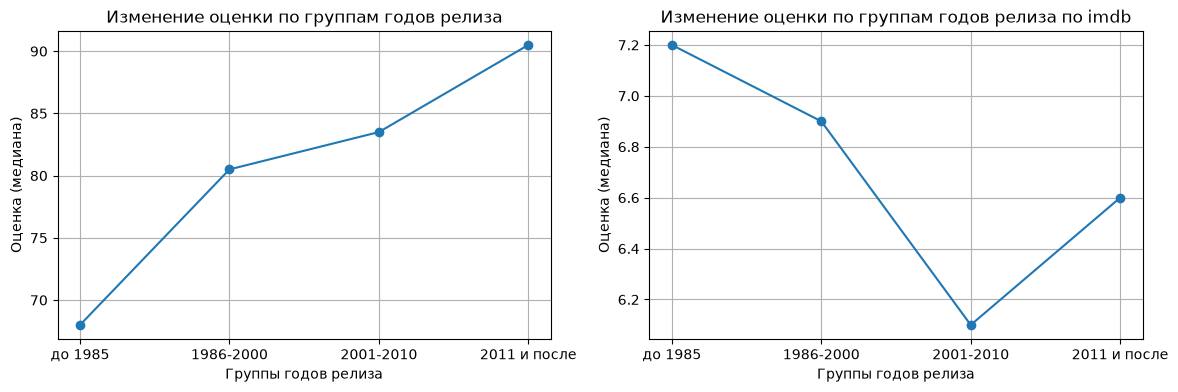

In [352]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rating_years.index, rating_years['median'], marker="o")
axes[0].set_title("Изменение оценки по группам годов релиза")
axes[0].set_xlabel("Группы годов релиза")
axes[0].set_ylabel("Оценка (медиана)")
axes[0].grid(True)

axes[1].plot(rating_years_imdbRating.index, rating_years_imdbRating['median'], marker="o")
axes[1].set_title("Изменение оценки по группам годов релиза по imdb")
axes[1].set_xlabel("Группы годов релиза")
axes[1].set_ylabel("Оценка (медиана)")
axes[1].grid(True)
plt.show()


- проверям корректность, удаляя строки, где imdbRating пустой

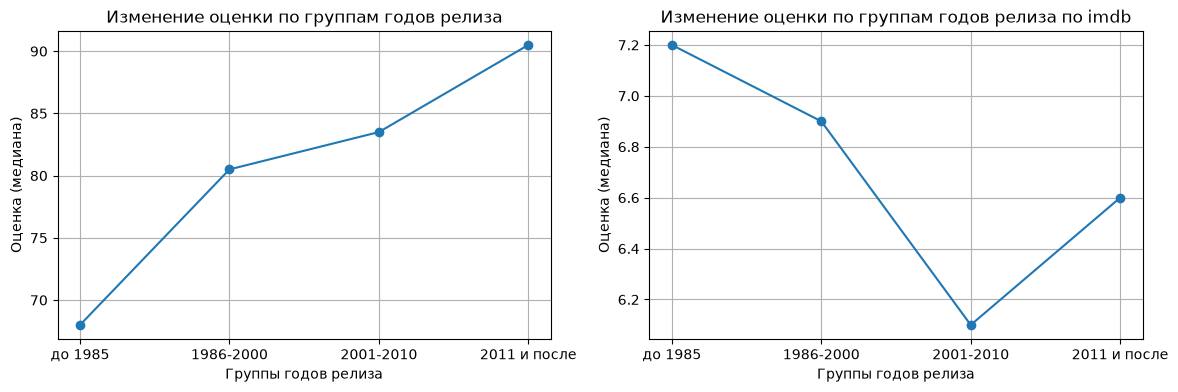

In [353]:
df_rating_2 = df_rating.dropna(subset=["imdbRating"])
rating_years_2 = (df_rating.groupby('годы релиза')["user rating score"].agg(['mean', 'median','count']))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rating_years_2.index, rating_years_2['median'], marker="o")
axes[0].set_title("Изменение оценки по группам годов релиза")
axes[0].set_xlabel("Группы годов релиза")
axes[0].set_ylabel("Оценка (медиана)")
axes[0].grid(True)

axes[1].plot(rating_years_imdbRating.index, rating_years_imdbRating['median'], marker="o")
axes[1].set_title("Изменение оценки по группам годов релиза по imdb")
axes[1].set_xlabel("Группы годов релиза")
axes[1].set_ylabel("Оценка (медиана)")
axes[1].grid(True)
plt.show()

 #### вывод 10:
 Основной: существует слабая корреляция между годом выпуска и оценкой. Можно предположить, что создатели контента стали более ориентированы на аудиторию и стараются соответствовать запросам ИЛИ современный зритель низко оценивает контент предыдуших лет.

 Дополнительный по imdb: данные показывают тенденцию к снижению оценок за фильмы, выпушенных 2010 года, но после идет рост оценок


In [354]:
df_rating['imdbVotes'] = df_rating['imdbVotes'].str.replace(",", "").astype(float)

In [355]:
rating_n = {"NR": 0, "UR": 0,
             "G": 1.1, "TV-G": 1.2,"TV-Y": 1.3,
             "PG-13": 2.1, "TV-14": 2.2,
             "PG": 3.1,"TV-PG": 3.2,"TV-Y7": 3.3, "TV-Y7-FV": 3.4,
             "R": 4.1, "TV-MA": 4.2,}
df_rating["rating_n"] = df_rating["rating"].map(rating_n)

In [356]:
corr_m2 = df_rating[["release year", 'imdbRating', 'imdbVotes', "user rating score", 'rating_n']].corr()

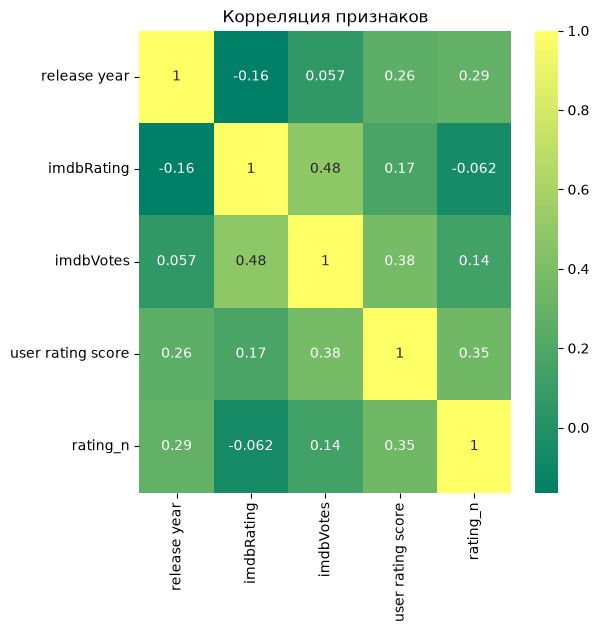

In [357]:
plt.figure(figsize= (6, 6))
sns.heatmap(corr_m2, annot=True, cmap='summer')
plt.title("Корреляция признаков")
plt.show()

 #### вывод 11:
- данные по user rating core умеренно коррелируют полоительно с данными с рейтингами, т.е. чем более взрослый контент, тем выше рейтинг
- user rating core умеренно коррелируют с кол-вом голосов по imdbvotes, из чего можно предположить, что более популярные фильмы по оценкам имеют выше рейтинг (это подтверждается корреляцией imdbvotes с imdbRating)

In [358]:
top20_imdbvotes = (df_rating.sort_values("imdbVotes", ascending=False)[["title", "imdbVotes", "imdbRating", "user rating score"]].head(20))
top20_imdbvotes

,title,imdbVotes,imdbRating,user rating score
73,Zootopia,625023.000,8.000,97.000
354,Kung Fu Panda,574537.000,7.600,91.000
175,Twilight,522520.000,5.400,89.000
169,10 Things I Hate About You,448378.000,7.400,68.000
265,The Nightmare Before Christmas,409668.000,7.900,84.000
75,Finding Dory,331036.000,7.200,98.000
475,Corpse Bride,324184.000,7.400,91.000
170,Grease,323963.000,7.200,86.000
171,How to Lose a Guy in 10 Days,320607.000,6.500,56.000
305,The Jungle Book,304379.000,7.300,97.000


In [359]:
top20_imdbvotes[['imdbRating', 'user rating score']].describe()

,imdbRating,user rating score
count,20.000,20.000
mean,7.205,87.850
std,0.662,10.757
min,5.400,56.000
25%,7.100,83.750
50%,7.350,91.000
75%,7.525,95.000
max,8.100,98.000


 #### вывод 12:
 Т.к. в изначальном датасете оценки выбраны с одинаковым размером аудитории, то по датасету IMDB c помощью колонок imdbVotes с кол-вом оценком удалось определить самые популярные фильмы. 

 Изучая два источника оценок было выявлено: минимальные оценки 5.4/10 и 56/100 самых популярных фильмов, что показывает, что фильмы с высокой популярностью все же могут оцениваться низко

_______ 

## финальное заключение по блоку

## Согласно выводам выше, можно составить примерный сценарий успеха фильма: 
### - рейтинг и возрастная категория - R, TV-MA, врослые (вывод 11)
### - новые фильмы получают более высокие оценки по сравнению с релизами прошлых лет (вывод 10)
### - наличие в фильме scary, mild, rude и violence (вывод 9)
### - фильм с большим бюджетом скорее всего принесет высокую доходность (вывод 2) - доп вывод


## Риски:
### - низкая оценка даже при большой популярности (вывод 12)
### - новые фильмы могут быть мене окупаемы (вывод 3) - доп вывод 